# Exploratory Data Analysis: Student Habits and Academic Performance

*Solution example — revised version of `EDA_final.ipynb`*

**Structure**
0. Problem definition and setup
1. Data understanding
2. Data quality and cleaning
3. Univariate analysis
4. Bivariate analysis
5. Multivariate analysis
6. Summary: answers to the research questions, limitations and next steps

> Every section ends with a **Conclusion** block. Each conclusion states *what we see* (with a number), *what it means*, and *what we do next*.

## 0. Problem definition and setup
### 0.1. Context, objectives and research questions

**Context.** Universities want to know which everyday habits (study time, sleep, screen time, exercise, etc.) are linked to exam results, so that student-support services can focus on the right behaviours. This notebook explores a dataset of 1,000 students with 14 habit/background variables and one outcome (`exam_score`).

**Objectives**
1. Assess whether the data is clean and reliable enough for analysis.
2. Identify which habits and characteristics are associated with exam scores, and how strongly.
3. Prepare a justified list of features for a later predictive model.

**Research questions (RQ)**

| # | Research question | Answered in |
|---|---|---|
| RQ1 | Is the data complete, consistent and plausible enough for analysis? | §2 |
| RQ2 | Which numerical habits have the strongest association with exam score? | §4.1, §5.3 |
| RQ3 | Do exam scores differ across demographic/background groups (gender, parental education, part-time job, diet, internet, extracurricular)? | §4.2, §5.3 |
| RQ4 | Are any predictors redundant (strongly correlated with each other)? | §5.1, §5.2 |
| RQ5 | Which features should be kept for a predictive model of exam score? | §5.3, §6 |

**Significance level:** α = 0.05 for all tests. Because we run many tests, p-values are always reported together with an **effect size**, and we focus on effect size when judging practical importance.

### 0.2. Import libraries and load data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.3f}".format)

data = pd.read_csv("student_habits_performance.csv")
data.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.000,1.200,1.100,No,85.000,8.000,Fair,6,Master,Average,8,Yes,56.200
1,S1001,20,Female,6.900,2.800,2.300,No,97.300,4.600,Good,6,High School,Average,8,No,100.000
2,S1002,21,Male,1.400,3.100,1.300,No,94.800,8.000,Poor,1,High School,Poor,1,No,34.300
3,S1003,23,Female,1.000,3.900,1.000,No,71.000,9.200,Poor,4,Master,Good,1,Yes,26.800
4,S1004,19,Female,5.000,4.400,0.500,No,90.900,4.900,Fair,3,Master,Good,1,No,66.400


## 1. Data understanding
### 1.1. Dataset overview

In [2]:
print("Shape:", data.shape)
data.info()

Shape: (1000, 16)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    str    
 12  internet_quality               1000 non-nu

**Conclusion**
- The dataset has **1,000 rows (one per student) and 16 columns**: 1 identifier (`student_id`), 1 target (`exam_score`), 8 numerical and 6 categorical predictors.
- Data types are correct: no numerical column was read as text.
- Only `parental_education_level` has missing values (909 non-null → 91 missing). This is investigated in §2.1.
- `student_id` is an identifier only and is excluded from the analysis.

### 1.2. Variable dictionary
No official data dictionary was provided. Meanings are inferred from the column names; the **valid range** is a domain assumption, and the **observed range** is computed from the data so the two can be compared.

In [3]:
target = "exam_score"
num_cols = ["age", "study_hours_per_day", "social_media_hours", "netflix_hours",
            "attendance_percentage", "sleep_hours", "exercise_frequency",
            "mental_health_rating"]
nom_cols = ["gender", "part_time_job", "parental_education_level",
            "extracurricular_participation"]
ord_cols = ["diet_quality", "internet_quality"]
cat_cols = nom_cols + ord_cols

ORDER = {
    "diet_quality": ["Poor", "Fair", "Good"],
    "internet_quality": ["Poor", "Average", "Good"],
    "parental_education_level": ["High School", "Bachelor", "Master"],
}

observed = data[num_cols + [target]].agg(["min", "max"]).T
observed["observed range"] = observed["min"].astype(str) + " – " + observed["max"].astype(str)
observed[["observed range"]]

,observed range
age,17.0 – 24.0
study_hours_per_day,0.0 – 8.3
social_media_hours,0.0 – 7.2
netflix_hours,0.0 – 5.4
attendance_percentage,56.0 – 100.0
sleep_hours,3.2 – 10.0
exercise_frequency,0.0 – 6.0
mental_health_rating,1.0 – 10.0
exam_score,18.4 – 100.0


| Column | Meaning | Unit | Type | Assumed valid range | Observed |
|---|---|---|---|---|---|
| `age` | Student age | years | numerical (discrete) | 16 – 30 (university students) | 17 – 24 |
| `gender` | Gender | – | nominal | Female / Male / Other | 3 levels |
| `study_hours_per_day` | Self-study time | hours/day | numerical (continuous) | 0 – 24 | 0 – 8.3 |
| `social_media_hours` | Time on social media | hours/day | numerical (continuous) | 0 – 24 | 0 – 7.2 |
| `netflix_hours` | Time on Netflix/streaming | hours/day | numerical (continuous) | 0 – 24 | 0 – 5.4 |
| `part_time_job` | Has a part-time job | – | binary | Yes / No | 2 levels |
| `attendance_percentage` | Class attendance | % | numerical (continuous) | 0 – 100 | 56 – 100 |
| `sleep_hours` | Sleep per night | hours/day | numerical (continuous) | 0 – 24 | 3.2 – 10 |
| `diet_quality` | Self-rated diet | – | **ordinal** | Poor < Fair < Good | 3 levels |
| `exercise_frequency` | Exercise sessions | days/week | numerical (discrete) | 0 – 7 | 0 – 6 |
| `parental_education_level` | Highest parental education | – | ordinal | High School < Bachelor < Master | 3 levels + missing |
| `internet_quality` | Home internet quality | – | **ordinal** | Poor < Average < Good | 3 levels |
| `mental_health_rating` | Self-rated mental health | score | ordinal treated as numerical | 1 – 10 | 1 – 10 |
| `extracurricular_participation` | Takes part in extracurricular activities | – | binary | Yes / No | 2 levels |
| `exam_score` | Final exam score (**target**) | points | numerical (continuous) | 0 – 100 | 18.4 – 100 |

**Conclusion**: every observed range sits inside its assumed valid range, so there are no impossible values (this is checked formally in §2.4). `mental_health_rating` is a 1–10 rating scale; it is ordinal in nature but has 10 evenly spaced levels, so we treat it as numerical and use rank-based (Spearman) methods to stay safe.

### 1.3. Summary statistics

In [4]:
summary = data[num_cols + [target]].describe().T
summary["mean - median"] = summary["mean"] - summary["50%"]
summary["skew"] = data[num_cols + [target]].skew()
summary

,count,mean,std,min,25%,50%,75%,max,mean - median,skew
age,1000.000,20.498,2.308,17.000,18.750,20.000,23.000,24.000,0.498,0.008
study_hours_per_day,1000.000,3.550,1.469,0.000,2.600,3.500,4.500,8.300,0.050,0.054
social_media_hours,1000.000,2.506,1.172,0.000,1.700,2.500,3.300,7.200,0.006,0.120
netflix_hours,1000.000,1.820,1.075,0.000,1.000,1.800,2.525,5.400,0.020,0.237
attendance_percentage,1000.000,84.132,9.399,56.000,78.000,84.400,91.025,100.000,-0.268,-0.238
sleep_hours,1000.000,6.470,1.226,3.200,5.600,6.500,7.300,10.000,-0.030,0.091
exercise_frequency,1000.000,3.042,2.025,0.000,1.000,3.000,5.000,6.000,0.042,-0.032
mental_health_rating,1000.000,5.438,2.848,1.000,3.000,5.000,8.000,10.000,0.438,0.038
exam_score,1000.000,69.602,16.889,18.400,58.475,70.500,81.325,100.000,-0.898,-0.156


In [5]:
data[cat_cols].describe().T

,count,unique,top,freq
gender,1000,3,Female,481
part_time_job,1000,2,No,785
parental_education_level,909,3,High School,392
extracurricular_participation,1000,2,No,682
diet_quality,1000,3,Fair,437
internet_quality,1000,3,Good,447


**Conclusion**
- For every numerical variable the mean and median differ by less than 1 unit and |skew| ≤ 0.24, so the distributions are **roughly symmetric**. No log-transformation is needed.
- The average student studies **3.6 h/day**, sleeps **6.5 h**, spends **2.5 h** on social media and **1.8 h** on Netflix, and attends **84%** of classes.
- `exam_score` has mean **69.6** and a wide spread (SD = 16.9, range 18.4–100). The maximum is exactly **100**, which may indicate a ceiling (checked in §2.6).
- Categorical variables have 2–3 levels each; the most frequent levels are shown under `top` (e.g. `No` for part-time job, 785 of 1,000).

## 2. Data quality and cleaning
### 2.1. Missing values

In [6]:
missing = data.isna().sum()
missing_pct = (missing / len(data) * 100).round(1)
pd.DataFrame({"n_missing": missing, "pct": missing_pct}).query("n_missing > 0")

,n_missing,pct
parental_education_level,91,9.100


In [7]:
# Hidden missing values written as text (e.g. "", "?", "NA")
hidden_tokens = ["", "?", "NA", "N/A", "null", "none", "-"]
{col: data[col].dropna().str.strip().str.lower().isin([t.lower() for t in hidden_tokens]).sum()
 for col in cat_cols}

{'gender': np.int64(0),
 'part_time_job': np.int64(0),
 'parental_education_level': np.int64(0),
 'extracurricular_participation': np.int64(0),
 'diet_quality': np.int64(0),
 'internet_quality': np.int64(0)}

**Is the missingness random?** If students with missing `parental_education_level` are systematically different (e.g. lower scores), simply filling or dropping them could bias the results. We compare the two groups on the target and on other variables.

In [8]:
is_missing = data["parental_education_level"].isna()

rows = []
for col in num_cols + [target]:
    p = stats.mannwhitneyu(data.loc[is_missing, col], data.loc[~is_missing, col]).pvalue
    rows.append([col, "Mann–Whitney U", data.loc[is_missing, col].mean(), data.loc[~is_missing, col].mean(), p])
for col in [c for c in cat_cols if c != "parental_education_level"]:
    p = stats.chi2_contingency(pd.crosstab(is_missing, data[col]))[1]
    rows.append([col, "Chi-square", np.nan, np.nan, p])

mcar = pd.DataFrame(rows, columns=["variable", "test", "mean (missing)", "mean (observed)", "p_value"])
mcar["p_holm"] = multipletests(mcar["p_value"], method="holm")[1]
mcar.sort_values("p_value")

,variable,test,mean (missing),mean (observed),p_value,p_holm
4,attendance_percentage,Mann–Whitney U,86.643,83.880,0.018,0.245
9,gender,Chi-square,NaN,NaN,0.240,1.000
3,netflix_hours,Mann–Whitney U,1.713,1.830,0.277,1.000
7,mental_health_rating,Mann–Whitney U,5.154,5.466,0.317,1.000
0,age,Mann–Whitney U,20.725,20.475,0.330,1.000
1,study_hours_per_day,Mann–Whitney U,3.664,3.539,0.376,1.000
6,exercise_frequency,Mann–Whitney U,2.945,3.052,0.622,1.000
13,internet_quality,Chi-square,NaN,NaN,0.693,1.000
12,diet_quality,Chi-square,NaN,NaN,0.699,1.000
8,exam_score,Mann–Whitney U,70.034,69.558,0.708,1.000


**Conclusion**
- Only `parental_education_level` has missing values: **91 rows (9.1%)**. No hidden missing tokens were found in any text column.
- Students with and without this information have almost the same mean exam score (**70.0 vs 69.6**, Mann–Whitney p = 0.71), and none of the other variables differ between the two groups after Holm correction (smallest adjusted p = 0.25; attendance had a raw p = 0.018, but this is expected by chance when running 14 tests). This is **consistent with data missing completely at random (MCAR)**.
- **Decision:** keep the 91 rows and code the missing value as a separate level `"Unknown"`. Deleting them would waste 9% of the data, and imputing the mode ("High School") would invent information. Because missingness looks random, this choice should not bias the results.

### 2.2. Duplicates

In [9]:
print("Duplicate student_id          :", data["student_id"].duplicated().sum())
print("Duplicate rows (all columns)  :", data.duplicated().sum())
print("Duplicate rows (ignoring id)  :", data.drop(columns="student_id").duplicated().sum())

Duplicate student_id          : 0
Duplicate rows (all columns)  : 0
Duplicate rows (ignoring id)  : 0


**Conclusion**: there are **no duplicated students** — every `student_id` is unique and no two rows have identical values even after ignoring the ID. No action is needed.

### 2.3. Data types and format

In [10]:
# Integer columns should contain whole numbers only; float columns should have at most 1 decimal place
def max_decimals(s):
    if pd.api.types.is_integer_dtype(s):
        return 0
    return s.astype(str).str.split(".").str[1].str.rstrip("0").str.len().max()

fmt = pd.DataFrame({
    "dtype": data[num_cols + [target]].dtypes.astype(str),
    "max decimals": data[num_cols + [target]].apply(max_decimals),
})
fmt

,dtype,max decimals
age,int64,0
study_hours_per_day,float64,1
social_media_hours,float64,1
netflix_hours,float64,1
attendance_percentage,float64,1
sleep_hours,float64,1
exercise_frequency,int64,0
mental_health_rating,int64,0
exam_score,float64,1


**Conclusion**: count-type variables (`age`, `exercise_frequency`, `mental_health_rating`) are stored as integers, and all continuous variables are recorded with at most **one decimal place**. The format is consistent, so no conversion is required. For analysis, the two ordinal variables are additionally encoded as ordered numbers (§2.7).

### 2.4. Invalid values (domain rules)
We check each variable against its domain rule from §1.2, plus one cross-variable rule: the time spent studying, sleeping, on social media and on Netflix cannot exceed 24 hours in a day.

In [11]:
rules = {
    "age":                   data["age"].between(16, 30),
    "study_hours_per_day":   data["study_hours_per_day"].between(0, 24),
    "social_media_hours":    data["social_media_hours"].between(0, 24),
    "netflix_hours":         data["netflix_hours"].between(0, 24),
    "attendance_percentage": data["attendance_percentage"].between(0, 100),
    "sleep_hours":           data["sleep_hours"].between(0, 24),
    "exercise_frequency":    data["exercise_frequency"].between(0, 7),
    "mental_health_rating":  data["mental_health_rating"].between(1, 10),
    "exam_score":            data["exam_score"].between(0, 100),
}
total_hours = data[["study_hours_per_day", "sleep_hours", "social_media_hours", "netflix_hours"]].sum(axis=1)
rules["total daily hours <= 24"] = total_hours <= 24

violations = pd.Series({k: (~v).sum() for k, v in rules.items()}, name="n_violations")
print(violations.to_string())
print(f"\nTotal daily hours (study + sleep + social media + Netflix): max = {total_hours.max():.1f} h, "
      f"rows above 20 h = {(total_hours > 20).sum()}")

age                        0
study_hours_per_day        0
social_media_hours         0
netflix_hours              0
attendance_percentage      0
sleep_hours                0
exercise_frequency         0
mental_health_rating       0
exam_score                 0
total daily hours <= 24    0

Total daily hours (study + sleep + social media + Netflix): max = 21.5 h, rows above 20 h = 16


**Conclusion**: **no row breaks any domain rule** and the combined daily hours never exceed 24 h (maximum 21.5 h; only 16 students exceed 20 h, which is unusual but possible). All values are therefore kept.

### 2.5. Categorical consistency

In [12]:
for col in cat_cols:
    s = data[col].dropna()
    print(f"{col:32s} levels = {sorted(s.unique())} | "
          f"leading/trailing spaces = {(s != s.str.strip()).sum()} | "
          f"case variants = {s.nunique() - s.str.lower().nunique()}")

gender                           levels = ['Female', 'Male', 'Other'] | leading/trailing spaces = 0 | case variants = 0
part_time_job                    levels = ['No', 'Yes'] | leading/trailing spaces = 0 | case variants = 0
parental_education_level         levels = ['Bachelor', 'High School', 'Master'] | leading/trailing spaces = 0 | case variants = 0
extracurricular_participation    levels = ['No', 'Yes'] | leading/trailing spaces = 0 | case variants = 0
diet_quality                     levels = ['Fair', 'Good', 'Poor'] | leading/trailing spaces = 0 | case variants = 0
internet_quality                 levels = ['Average', 'Good', 'Poor'] | leading/trailing spaces = 0 | case variants = 0


**Conclusion**: all categorical columns have clean, consistent labels — no leading/trailing spaces, no case variants (e.g. `male` vs `Male`) and no spelling variants.

*Note:* the original notebook reported "91 extra spaces" for `parental_education_level`. This was a false alarm: `NaN != NaN.strip()` evaluates to `True`, so the 91 **missing** values were counted as "spaces". Using `.dropna()` before the check removes this problem.

### 2.6. Outliers and boundary values
We use two checks: (1) the IQR rule for statistical outliers, and (2) counts of values sitting exactly on a boundary (0 or the maximum), which can reveal **floor/ceiling (clipping) effects**.

In [13]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()

cont = ["study_hours_per_day", "social_media_hours", "netflix_hours",
        "attendance_percentage", "sleep_hours", target]
boundary = pd.DataFrame({
    "IQR outliers": data[num_cols + [target]].apply(iqr_outliers),
    "n at min": data[num_cols + [target]].apply(lambda s: (s == s.min()).sum()),
    "min": data[num_cols + [target]].min(),
    "n at max": data[num_cols + [target]].apply(lambda s: (s == s.max()).sum()),
    "max": data[num_cols + [target]].max(),
})
boundary.loc[cont]

,IQR outliers,n at min,min,n at max,max
study_hours_per_day,7,13,0.000,1,8.300
social_media_hours,5,21,0.000,1,7.200
netflix_hours,4,59,0.000,1,5.400
attendance_percentage,3,1,56.000,66,100.000
sleep_hours,2,1,3.200,2,10.000
exam_score,2,1,18.400,48,100.000


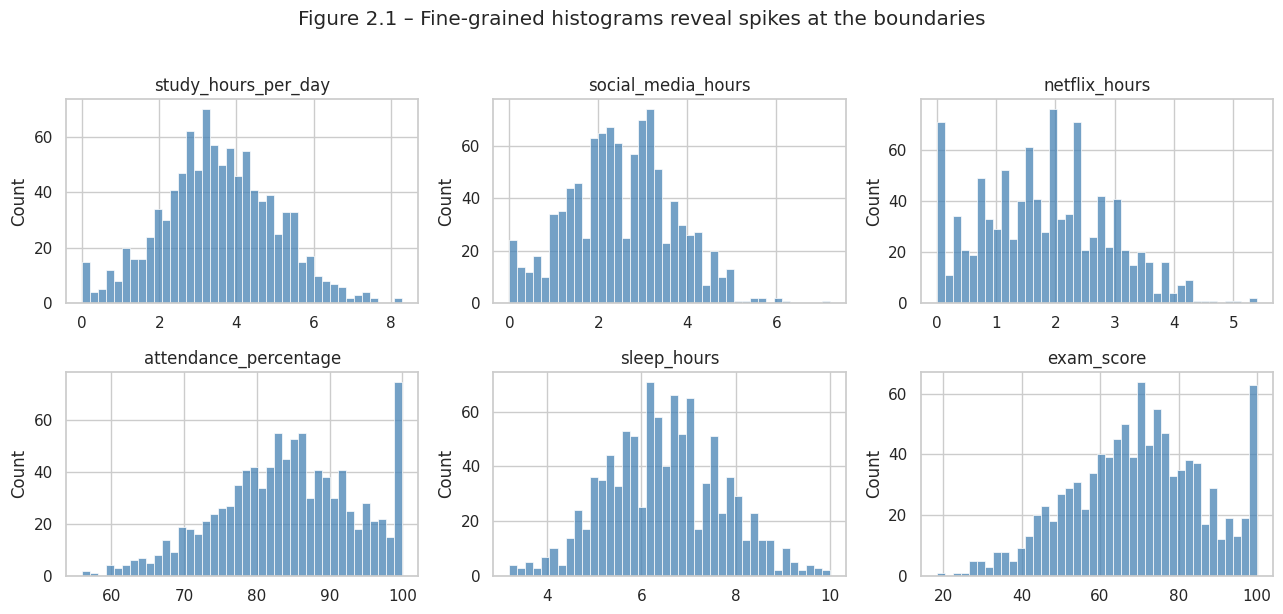

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, col in zip(axes.flat, cont):
    sns.histplot(data[col], bins=40, ax=ax, color="steelblue")
    ax.set_title(col)
    ax.set_xlabel("")
fig.suptitle("Figure 2.1 – Fine-grained histograms reveal spikes at the boundaries", y=1.02)
plt.tight_layout()
plt.show()

**Conclusion**
- The IQR rule flags only **2–7 points per variable** (< 1% of rows). These values are plausible (e.g. 8.3 study hours/day, 3.2 hours of sleep) and within the domain rules, so they are **real but extreme observations, not errors**. They are kept.
- More importantly, several variables show **spikes at their boundaries**:
  - `exam_score`: **48 students (4.8%) score exactly 100** → a **ceiling effect**. Scores were probably capped at 100, so the true ability of top students is hidden.
  - `attendance_percentage`: **66 students at exactly 100%** → same ceiling pattern.
  - `netflix_hours` (59), `social_media_hours` (21) and `study_hours_per_day` (13) have spikes at **0** → a floor effect.
- These spikes are typical of **simulated data that was generated from a distribution and then clipped** to a valid range. This is a limitation to report (§6) and it matters for modelling: a linear model will over-predict for the best students (see §5.4).

### 2.7. Cleaning decision log
| # | Issue | Evidence | Decision | Justification |
|---|---|---|---|---|
| 1 | Missing `parental_education_level` | 91 rows (9.1%) | Recode as `"Unknown"` | Missingness is consistent with MCAR (§2.1); keeps all rows |
| 2 | Duplicates | 0 found | No action | – |
| 3 | Invalid / impossible values | 0 violations | No action | All values within domain rules (§2.4) |
| 4 | Inconsistent labels | 0 found | No action | – |
| 5 | IQR outliers | 2–7 per variable | Keep | Plausible values, not errors |
| 6 | Ceiling at 100 (score, attendance) | 48 and 66 rows | Keep, flag as limitation | Cannot recover the true (uncapped) value; create a flag for later checks |
| 7 | Ordinal variables stored as text | `diet_quality`, `internet_quality` | Add ordered numeric versions (0, 1, 2) | Allows rank correlation with the target |
| 8 | `student_id` | Identifier | Exclude from analysis | Carries no information |

In [15]:
df = data.copy()

df["parental_education_level"] = df["parental_education_level"].fillna("Unknown")
df["diet_quality_num"] = df["diet_quality"].map({"Poor": 0, "Fair": 1, "Good": 2})
df["internet_quality_num"] = df["internet_quality"].map({"Poor": 0, "Average": 1, "Good": 2})
df["score_capped"] = (df[target] == 100).astype(int)

for col, levels in ORDER.items():
    extra = ["Unknown"] if col == "parental_education_level" else []
    df[col] = pd.Categorical(df[col], categories=levels + extra, ordered=True)

print("Remaining missing values:", df.isna().sum().sum())
print("Clean shape:", df.shape)

Remaining missing values: 0
Clean shape: (1000, 19)


**Conclusion (RQ1)**: after the checks above the data is **complete, consistent and within valid ranges**, so it is reliable enough for analysis. The two things to keep in mind are the **ceiling at 100** and the signs that the data is **simulated**, which limit how far the findings can be generalised to real students.

## 3. Univariate analysis
### 3.1. Target variable: `exam_score`

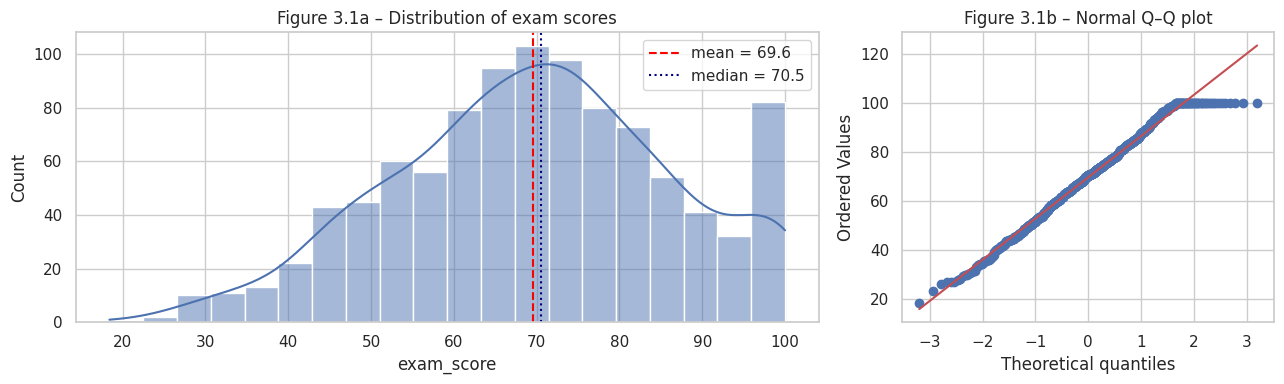

skew = -0.156 | kurtosis = -0.420 | score = 100: 48 | score < 40: 42


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [2, 1]})
sns.histplot(df[target], bins=20, kde=True, ax=axes[0])
axes[0].axvline(df[target].mean(), color="red", ls="--", label=f"mean = {df[target].mean():.1f}")
axes[0].axvline(df[target].median(), color="navy", ls=":", label=f"median = {df[target].median():.1f}")
axes[0].set_title("Figure 3.1a – Distribution of exam scores")
axes[0].legend()
stats.probplot(df[target], dist="norm", plot=axes[1])
axes[1].set_title("Figure 3.1b – Normal Q–Q plot")
plt.tight_layout()
plt.show()

print(f"skew = {df[target].skew():.3f} | kurtosis = {df[target].kurt():.3f} | "
      f"score = 100: {(df[target] == 100).sum()} | score < 40: {(df[target] < 40).sum()}")

**Conclusion**
- Exam scores are **approximately normal and centred around 70** (mean 69.6, median 70.5) with a slight left skew (skew = −0.16): a small tail of low performers goes down to 18.4.
- The histogram and the Q–Q plot both show a **spike at 100** (48 students). The right tail is cut off, so the distribution is **right-censored**, not truly normal.
- 42 students (4.2%) scored below 40, meaning very low performance is relatively rare.
- **Implication:** a linear model is a reasonable first choice for this target, but predictions near 100 will be biased; a capped model (e.g. Tobit) or clipping predictions to [0, 100] should be considered.

### 3.2. Numerical features

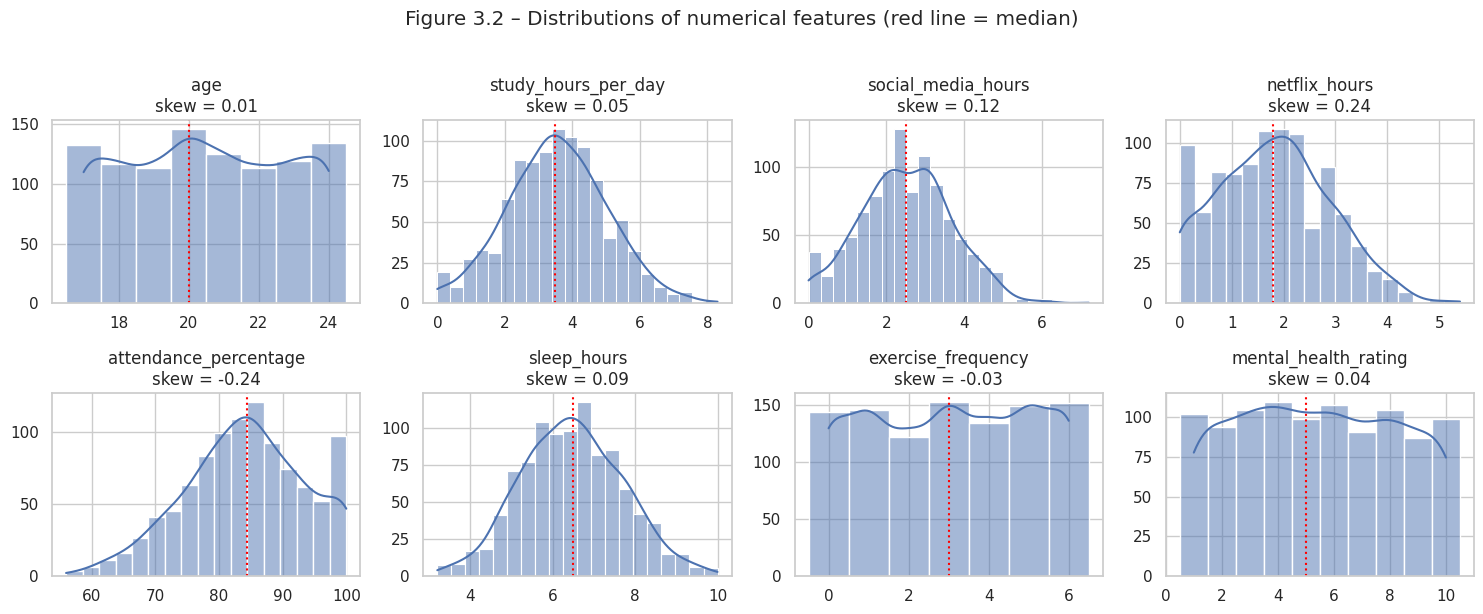

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(data=df, x=col, ax=ax, kde=True, discrete=(df[col].dtype == "int64"))
    ax.axvline(df[col].median(), color="red", ls=":")
    ax.set_title(f"{col}\nskew = {df[col].skew():.2f}")
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.suptitle("Figure 3.2 – Distributions of numerical features (red line = median)", y=1.02)
plt.tight_layout()
plt.show()

**Conclusion**
- Two groups of shapes can be seen:
  - **Bell-shaped** (approximately normal): `study_hours_per_day`, `social_media_hours`, `netflix_hours`, `sleep_hours`, `attendance_percentage`.
  - **Uniform** (flat): `age` (17–24), `exercise_frequency` (0–6) and `mental_health_rating` (1–10). Every value occurs about equally often, which is unusual for real survey data and is further evidence that the dataset is **simulated**.
- All |skew| ≤ 0.24, so **no transformation is required**.
- Boundary spikes are visible for `attendance_percentage` (at 100) and `netflix_hours` (at 0), as described in §2.6.
- `exercise_frequency` never reaches 7 days/week, which suggests the generator used a range of 0–6.

### 3.3. Categorical features

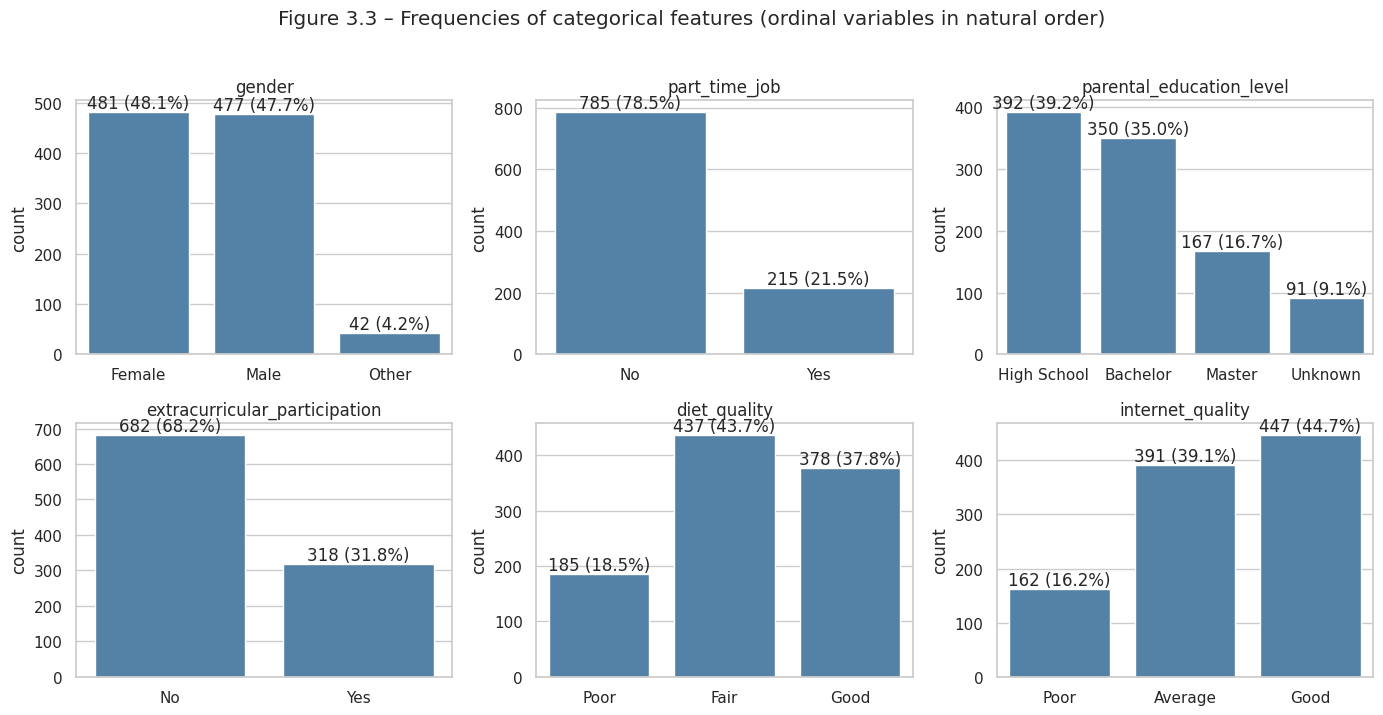

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, cat_cols):
    if isinstance(df[col].dtype, pd.CategoricalDtype):
        order = list(df[col].cat.categories)
    else:
        order = list(df[col].value_counts().index)
    counts = df[col].value_counts().reindex(order)
    sns.countplot(data=df, x=col, order=order, ax=ax, color="steelblue")
    ax.bar_label(ax.containers[0], labels=[f"{c} ({c / len(df):.1%})" for c in counts])
    ax.set_title(col)
    ax.set_xlabel("")
fig.suptitle("Figure 3.3 – Frequencies of categorical features (ordinal variables in natural order)", y=1.02)
plt.tight_layout()
plt.show()

**Conclusion**
- `gender` is balanced between Female (48.1%) and Male (47.7%), but **`Other` has only 42 students (4.2%)**. Estimates for this group will be imprecise, so conclusions about it should be cautious.
- Most students **do not** have a part-time job (78.5%) and **do not** take part in extracurricular activities (68.2%) — both binary variables are imbalanced (roughly 4:1 and 2:1).
- `parental_education_level` is dominated by High School (39.2%) and Bachelor (35.0%); Master is 16.7% and Unknown 9.1%.
- Ordinal variables: most students report **Fair** diet (43.7%) and **Good** internet (44.7%); the `Poor` level is the smallest group for both (18.5% and 16.2%).
- No level is extremely rare except `gender = Other`, so no levels need to be merged.

## 4. Bivariate analysis
### 4.1. Numerical features vs target
Pearson measures **linear** association; Spearman measures **monotonic** association and is robust to outliers. If the two are similar, the relationship is approximately linear.

In [19]:
corr_cols = num_cols + ["diet_quality_num", "internet_quality_num"]

def strength(r):
    r = abs(r)
    return "very strong" if r >= 0.7 else "moderate" if r >= 0.3 else "weak" if r >= 0.1 else "negligible"

rows = []
for col in corr_cols:
    r_p, p_p = stats.pearsonr(df[col], df[target])
    r_s, p_s = stats.spearmanr(df[col], df[target])
    rows.append([col, r_p, r_s, p_s])
corr_table = pd.DataFrame(rows, columns=["feature", "pearson_r", "spearman_rho", "p_value"]).set_index("feature")
corr_table["p_holm"] = multipletests(corr_table["p_value"], method="holm")[1]
corr_table["significant"] = corr_table["p_holm"] < 0.05
corr_table["strength"] = corr_table["spearman_rho"].apply(strength)
corr_table.sort_values("spearman_rho", key=abs, ascending=False)

,pearson_r,spearman_rho,p_value,p_holm,significant,strength
feature,,,,,,
study_hours_per_day,0.825,0.812,0.000,0.000,True,very strong
mental_health_rating,0.322,0.323,0.000,0.000,True,moderate
social_media_hours,-0.167,-0.166,0.000,0.000,True,weak
netflix_hours,-0.172,-0.165,0.000,0.000,True,weak
exercise_frequency,0.160,0.150,0.000,0.000,True,weak
sleep_hours,0.122,0.123,0.000,0.000,True,weak
attendance_percentage,0.090,0.094,0.003,0.012,True,negligible
internet_quality_num,-0.036,-0.046,0.148,0.444,False,negligible
diet_quality_num,0.015,0.014,0.663,1.000,False,negligible


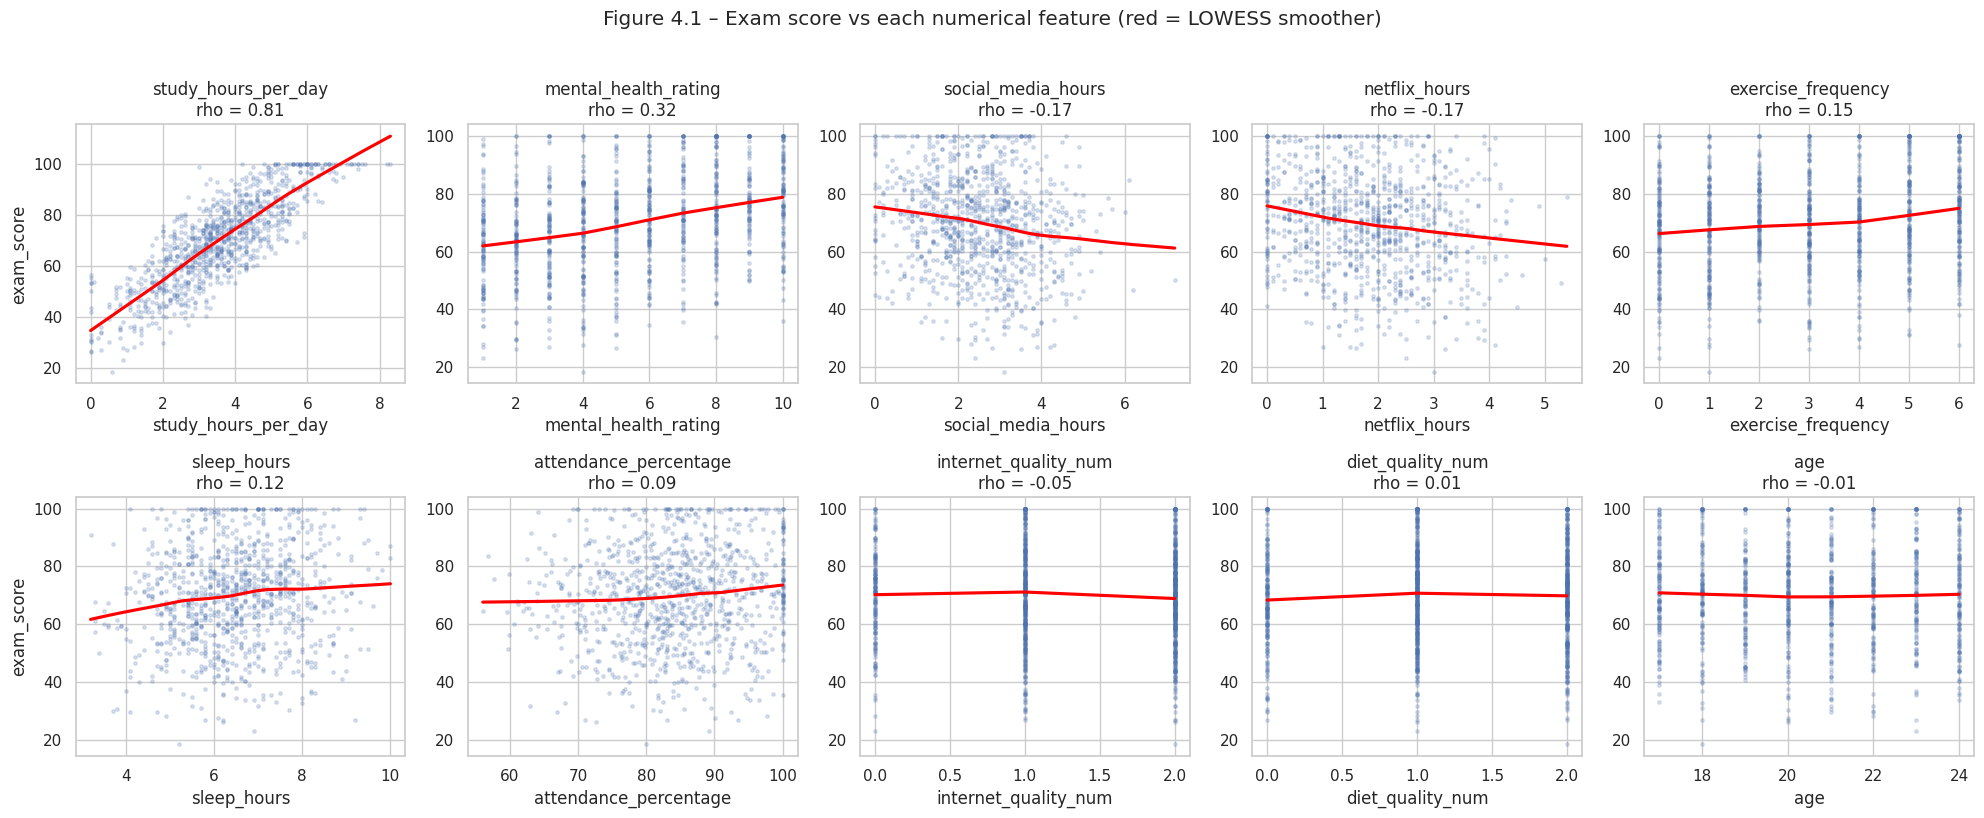

In [20]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, col in zip(axes.flat, corr_table.sort_values("spearman_rho", key=abs, ascending=False).index):
    sns.regplot(data=df, x=col, y=target, ax=ax, lowess=True,
                scatter_kws={"alpha": 0.2, "s": 6}, line_kws={"color": "red"})
    ax.set_title(f"{col}\nrho = {corr_table.loc[col, 'spearman_rho']:.2f}")
    ax.set_ylabel(target if ax in axes[:, 0] else "")
fig.suptitle("Figure 4.1 – Exam score vs each numerical feature (red = LOWESS smoother)", y=1.02)
plt.tight_layout()
plt.show()

Because `study_hours_per_day` is by far the strongest predictor, we look at it more closely by grouping students into study-time bands.

In [21]:
bands = pd.cut(df["study_hours_per_day"], bins=[-0.1, 1, 2, 3, 4, 5, 6, 9],
               labels=["0–1", "1–2", "2–3", "3–4", "4–5", "5–6", "6+"])
band_table = df.groupby(bands, observed=True)[target].agg(
    n="count", mean_score="mean", pct_score_100=lambda s: (s == 100).mean() * 100)
band_table["gain vs previous band"] = band_table["mean_score"].diff()
band_table

,n,mean_score,pct_score_100,gain vs previous band
study_hours_per_day,,,,
0–1,44,40.043,0.000,NaN
1–2,110,49.745,0.000,9.702
2–3,205,60.387,0.000,10.641
3–4,276,70.101,0.000,9.714
4–5,210,78.892,0.952,8.791
5–6,111,88.030,18.919,9.138
6+,44,97.768,56.818,9.738


**Conclusion (RQ2)**
- **Study time is by far the strongest factor**: ρ = **0.81** (very strong, positive). Moving from 0–1 to 3–4 hours/day raises the average score from **40 to 70**, i.e. about **+10 points per extra hour** of study.
- **Mental health rating** has a **moderate positive** association (ρ = 0.32): students with better self-rated mental health score higher.
- **Social media** (ρ = −0.17) and **Netflix** (ρ = −0.17) have **weak negative** associations; **exercise** (0.15), **sleep** (0.12) and **attendance** (0.09) have weak/negligible positive associations. All of these are still statistically significant after Holm correction (n = 1,000 gives high power even for small effects).
- `age`, `diet_quality_num` and `internet_quality_num` show **no association** (|ρ| < 0.05, not significant).
- Pearson ≈ Spearman for every feature and the LOWESS lines are almost straight, so the relationships are **approximately linear** — except at the top: the scatter plot shows a flat band of points at exactly 100, and in the 6+ hours band **57% of students score 100**. The mean gain per band stays at ≈ +9–10 points all the way up, so this is the **ceiling effect** from §2.6 (scores cannot exceed 100), not diminishing returns of studying.

### 4.2. Categorical features vs target
We use the **Kruskal–Wallis H test** (non-parametric; it does not require normality and is robust to the ceiling at 100) and the effect size **epsilon-squared** ε² = H / (n − 1). Rough guide: ε² < 0.01 negligible, 0.01–0.08 small, 0.08–0.26 medium, > 0.26 large.

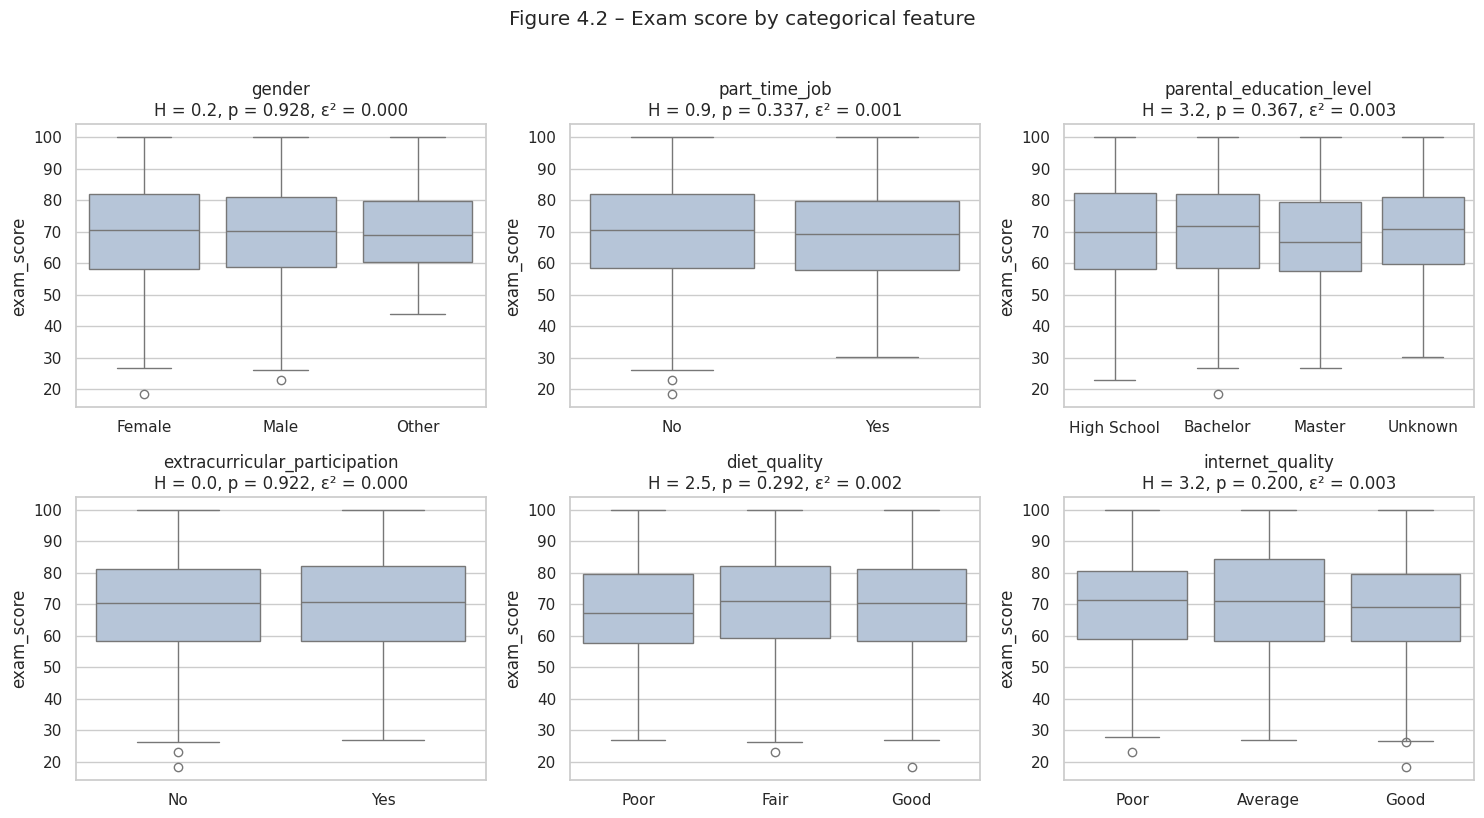

,H,p_value,epsilon_sq,median range (points),p_holm
feature,,,,,
internet_quality,3.221,0.200,0.003,2.100,1.000
parental_education_level,3.163,0.367,0.003,4.900,1.000
diet_quality,2.460,0.292,0.002,3.600,1.000
part_time_job,0.920,0.337,0.001,1.400,1.000
gender,0.150,0.928,0.000,1.700,1.000
extracurricular_participation,0.010,0.922,0.000,0.300,1.000


In [22]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
rows = []
for col, ax in zip(cat_cols, axes.flat):
    groups = [g[target].values for _, g in df.groupby(col, observed=True)]
    h, p = stats.kruskal(*groups)
    eps2 = h / (len(df) - 1)
    medians = df.groupby(col, observed=True)[target].median()
    rows.append([col, h, p, eps2, medians.max() - medians.min()])
    order = list(df[col].cat.categories) if isinstance(df[col].dtype, pd.CategoricalDtype) else sorted(df[col].unique())
    sns.boxplot(data=df, x=col, y=target, order=order, ax=ax, color="lightsteelblue")
    ax.set_title(f"{col}\nH = {h:.1f}, p = {p:.3f}, ε² = {eps2:.3f}")
    ax.set_xlabel("")
fig.suptitle("Figure 4.2 – Exam score by categorical feature", y=1.02)
plt.tight_layout()
plt.show()

kw = pd.DataFrame(rows, columns=["feature", "H", "p_value", "epsilon_sq", "median range (points)"]).set_index("feature")
kw["p_holm"] = multipletests(kw["p_value"], method="holm")[1]
kw.sort_values("epsilon_sq", ascending=False)

In [23]:
for col in cat_cols:
    print(f"{col:32s}", df.groupby(col, observed=True)[target].median().round(1).to_dict())

gender                           {'Female': 70.7, 'Male': 70.2, 'Other': 69.0}
part_time_job                    {'No': 70.6, 'Yes': 69.2}
parental_education_level         {'High School': 70.0, 'Bachelor': 71.7, 'Master': 66.8, 'Unknown': 71.0}
extracurricular_participation    {'No': 70.4, 'Yes': 70.6}
diet_quality                     {'Poor': 67.4, 'Fair': 71.0, 'Good': 70.3}
internet_quality                 {'Poor': 71.4, 'Average': 71.0, 'Good': 69.3}


**Conclusion (RQ3)**
- **None of the six categorical variables is significantly related to exam score** (all p ≥ 0.20; all Holm-adjusted p = 1.0) and all effect sizes are **negligible** (ε² ≤ 0.003).
- The differences between group medians are small — at most about **5 points** (parental education: Master 66.8 vs Bachelor 71.7), which is less than one-third of the score's standard deviation (16.9) and within random variation.
- **Gender:** Female 70.7, Male 70.2, Other 69.0 → no gender gap. (The `Other` group is small, n = 42, so we cannot rule out a small difference.)
- **Parental education:** no clear pattern; the trend even goes slightly in the "wrong" direction (Master lowest), which supports a *no-effect* reading.
- **Part-time job, extracurricular activities, diet and internet quality** also show no meaningful difference.
- **Implication:** in this dataset, exam performance depends on *what students do* (habits), not on *who they are* (background). The categorical features are candidates for removal from the predictive model (confirmed in §5.3).

## 5. Multivariate analysis
### 5.1. Correlation between predictors

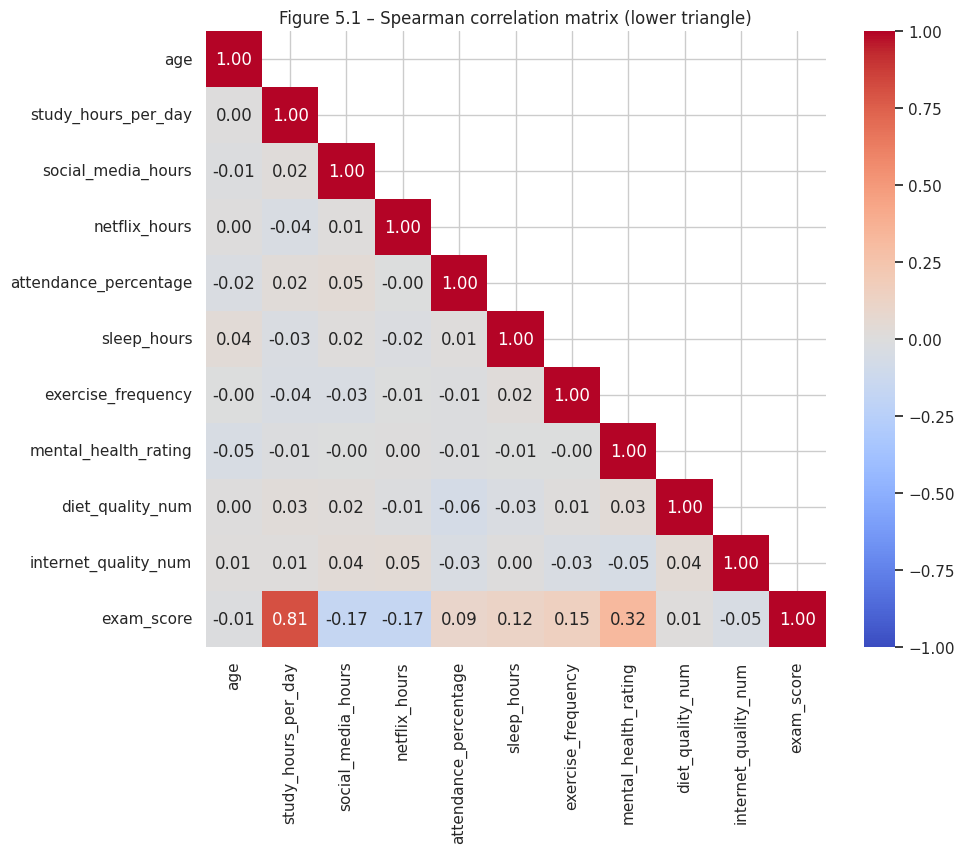

Largest |rho| between two predictors: 0.063


In [24]:
corr = df[corr_cols + [target]].corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Figure 5.1 – Spearman correlation matrix (lower triangle)")
plt.show()

pred_corr = corr.loc[corr_cols, corr_cols].where(~np.eye(len(corr_cols), dtype=bool))
print(f"Largest |rho| between two predictors: {pred_corr.abs().max().max():.3f}")

**Conclusion**
- The strongest correlation between any two **predictors** is only |ρ| = **0.06** — the predictors are practically **independent of each other**.
- This is surprising for real behaviour data (for example, we would expect more screen time to be linked to less sleep or less study time). It is another sign that the data was **simulated with independent variables**.
- The only strong correlations in the matrix are with the target (last row), which confirms §4.1.

### 5.2. Multicollinearity (VIF)

In [25]:
X = add_constant(df[corr_cols])
vif = pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
                index=X.columns).drop("const").sort_values(ascending=False)
vif.to_frame("VIF")

,VIF
internet_quality_num,1.010
attendance_percentage,1.009
diet_quality_num,1.008
mental_health_rating,1.006
social_media_hours,1.005
study_hours_per_day,1.005
age,1.004
sleep_hours,1.004
exercise_frequency,1.004
netflix_hours,1.003


**Conclusion (RQ4)**
- All VIF values are between **1.00 and 1.01**, far below the usual warning thresholds (5 or 10). There is **no multicollinearity**, so **no variable is redundant** and none needs to be removed for this reason.
- A practical consequence: each regression coefficient in §5.3 can be interpreted on its own, and marginal correlations (§4.1) and model coefficients should tell a similar story.

### 5.3. Joint effect of all predictors (multiple linear regression)
Correlations look at one variable at a time. A multiple regression shows how much each variable contributes **while holding the others constant**, and how much of the variation in exam scores the habits explain together. This is used here as an exploratory check, not as the final predictive model.

In [26]:
habits = ["study_hours_per_day", "mental_health_rating", "social_media_hours", "netflix_hours",
          "exercise_frequency", "sleep_hours", "attendance_percentage"]
others = ["age", "C(gender)", "C(part_time_job)", "C(parental_education_level, Treatment('High School'))",
          "C(diet_quality, Treatment('Poor'))", "C(internet_quality, Treatment('Poor'))",
          "C(extracurricular_participation)"]

df_cat = df.copy()
for c in ORDER:
    df_cat[c] = df_cat[c].astype(str)

m_study = smf.ols(f"{target} ~ study_hours_per_day", data=df_cat).fit()
m_habits = smf.ols(f"{target} ~ " + " + ".join(habits), data=df_cat).fit()
m_full = smf.ols(f"{target} ~ " + " + ".join(habits + others), data=df_cat).fit()

comparison = pd.DataFrame({
    "n predictors": [1, len(habits), int(m_full.df_model)],
    "R2": [m_study.rsquared, m_habits.rsquared, m_full.rsquared],
    "adj R2": [m_study.rsquared_adj, m_habits.rsquared_adj, m_full.rsquared_adj],
    "RMSE": [np.sqrt(m.mse_resid) for m in [m_study, m_habits, m_full]],
}, index=["M1: study hours only", "M2: 7 habit features", "M3: all features"])
comparison

,n predictors,R2,adj R2,RMSE
M1: study hours only,1,0.681,0.681,9.539
M2: 7 habit features,7,0.901,0.900,5.331
M3: all features,19,0.902,0.900,5.342


In [27]:
# Does adding all background/categorical variables improve M2? (nested F-test)
anova_lm(m_habits, m_full)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,992.000,28188.684,0.000,NaN,NaN,NaN
1,980.000,27967.984,12.000,220.700,0.644,0.805


In [28]:
# Standardised coefficients: effect of +1 SD in each habit, measured in SDs of exam score
z = df[habits + [target]].apply(lambda s: (s - s.mean()) / s.std())
m_std = smf.ols(f"{target} ~ " + " + ".join(habits), data=z).fit()

coef = pd.DataFrame({
    "coef (points per unit)": m_habits.params[habits],
    "95% CI low": m_habits.conf_int().loc[habits, 0],
    "95% CI high": m_habits.conf_int().loc[habits, 1],
    "std. beta": m_std.params[habits],
    "p_value": m_habits.pvalues[habits],
}).sort_values("std. beta", key=abs, ascending=False)
coef

,coef (points per unit),95% CI low,95% CI high,std. beta,p_value
study_hours_per_day,9.575,9.349,9.800,0.833,0.000
mental_health_rating,1.949,1.833,2.065,0.329,0.000
social_media_hours,-2.620,-2.903,-2.337,-0.182,0.000
exercise_frequency,1.452,1.288,1.615,0.174,0.000
sleep_hours,2.005,1.735,2.275,0.146,0.000
netflix_hours,-2.277,-2.585,-1.969,-0.145,0.000
attendance_percentage,0.145,0.109,0.180,0.081,0.000


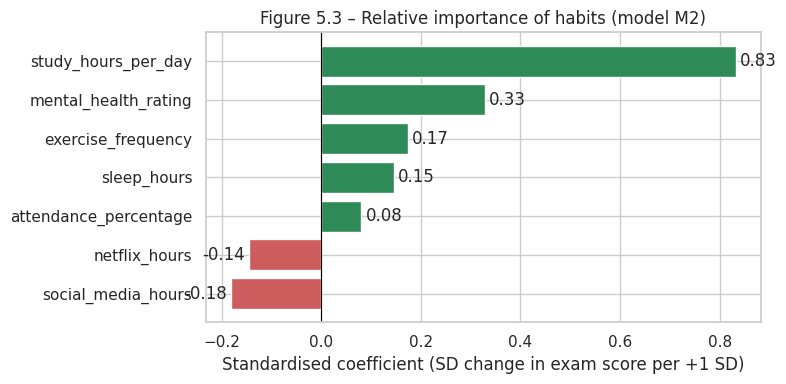

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))
c = coef["std. beta"].sort_values()
ax.barh(c.index, c.values, color=["indianred" if v < 0 else "seagreen" for v in c.values])
ax.axvline(0, color="black", lw=0.8)
ax.bar_label(ax.containers[0], fmt="%.2f", padding=3)
ax.set_xlabel("Standardised coefficient (SD change in exam score per +1 SD)")
ax.set_title("Figure 5.3 – Relative importance of habits (model M2)")
plt.tight_layout()
plt.show()

**Conclusion (RQ2, RQ3, RQ5)**
- **Study hours alone explain 68% of the variance** in exam scores (M1, R² = 0.68). Adding the other six habits raises this to **R² = 0.90** (M2), and the typical prediction error falls from about 9.5 to **5.3 points**.
- Adding **all seven background/categorical variables** (M3) gives **no improvement**: adjusted R² actually drops slightly (0.900 → 0.900) and the nested F-test for the 12 extra terms is not significant (F = 0.64, p = 0.81). This confirms §4.2: background variables do not add information.
- **Ranking of habits (standardised β):** study hours (**+0.83**) ≫ mental health (+0.33) > social media (−0.18) > exercise (+0.17) > sleep (+0.15) ≈ Netflix (−0.15) > attendance (+0.08). All seven are significant (p < 0.001).
- In practical units, **holding the other habits constant**: +1 study hour/day ≈ **+9.6 points**; +1 point of mental-health rating ≈ **+1.9**; +1 hour of sleep ≈ **+2.0**; +1 exercise day/week ≈ **+1.5**; +1 hour of social media ≈ **−2.6**; +1 hour of Netflix ≈ **−2.3**; +10 percentage points of attendance ≈ **+1.4**.
- **Insight:** social media, sleep and exercise looked *weak* in the simple correlations (|ρ| ≈ 0.12–0.17) but are clearly important in the joint model. Their effects were "hidden" behind the large variation caused by study time. Because the predictors are independent (§5.2), the model can separate these effects cleanly.

### 5.4. Model diagnostics: the ceiling effect

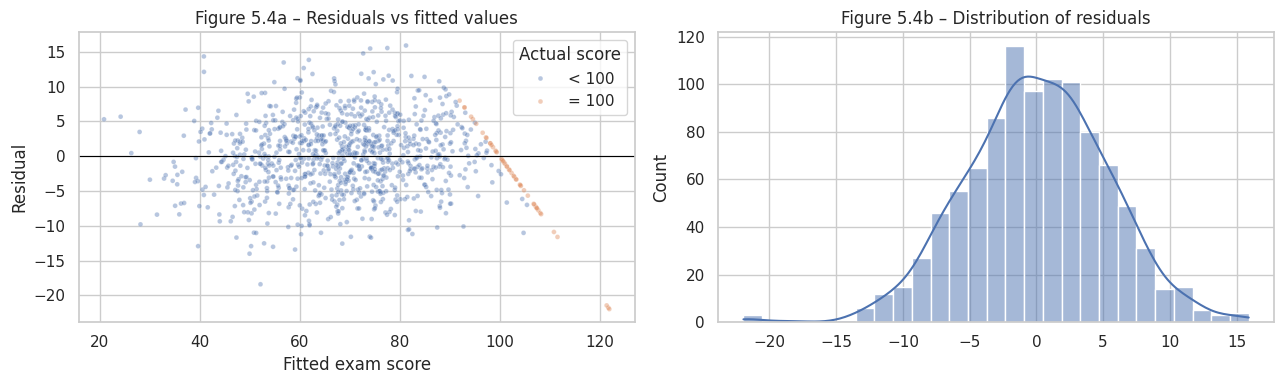

Predictions above 100: 37 (max = 122.0)
Mean residual for capped students (score = 100): -2.94


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.scatterplot(x=m_habits.fittedvalues, y=m_habits.resid, hue=df["score_capped"].map({0: "< 100", 1: "= 100"}),
                alpha=0.4, s=12, ax=axes[0])
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_xlabel("Fitted exam score")
axes[0].set_ylabel("Residual")
axes[0].set_title("Figure 5.4a – Residuals vs fitted values")
axes[0].legend(title="Actual score")
sns.histplot(m_habits.resid, kde=True, ax=axes[1])
axes[1].set_title("Figure 5.4b – Distribution of residuals")
plt.tight_layout()
plt.show()

print(f"Predictions above 100: {(m_habits.fittedvalues > 100).sum()} "
      f"(max = {m_habits.fittedvalues.max():.1f})")
print(f"Mean residual for capped students (score = 100): {m_habits.resid[df['score_capped'] == 1].mean():.2f}")

**Conclusion**
- For most students the residuals are centred on zero with constant spread, so the linear model fits well.
- At the top, however, the model predicts scores **above 100** for 37 students (up to 122), and residuals for students who scored exactly 100 are **negative on average (−2.9 points)**: the model over-predicts because the real scores were capped. The same pattern is visible in Figure 4.1 (flattening of the curve above 6 study hours).
- **Implication for modelling:** clip predictions to [0, 100], or use a model that handles censoring (e.g. Tobit regression) or a tree-based model that naturally saturates.

### 5.5. Interaction check
Does the benefit of studying depend on other habits? We test two plausible interactions. Because this is exploratory, results are treated as hypotheses, not findings.

In [31]:
inter = []
for term in ["C(part_time_job)", "mental_health_rating"]:
    m = smf.ols(f"{target} ~ " + " + ".join(habits) + f" + study_hours_per_day:{term}"
                + (f" + {term}" if term.startswith("C(") else ""), data=df_cat).fit()
    name = [k for k in m.params.index if ":" in k][0]
    inter.append([name, m.params[name], m.pvalues[name], m.rsquared_adj - m_habits.rsquared_adj])
pd.DataFrame(inter, columns=["interaction", "coef", "p_value", "gain in adj R2"])

,interaction,coef,p_value,gain in adj R2
0,study_hours_per_day:C(part_time_job)[T.Yes],-0.354,0.189,0.000
1,study_hours_per_day:mental_health_rating,-0.090,0.034,0.000


**Conclusion**
- *Study hours × part-time job:* not significant (p = 0.19). The benefit of studying is the same for students with and without a job.
- *Study hours × mental health:* nominally significant (p = 0.034), but it would not survive a correction for two tests (Holm p ≈ 0.07), the coefficient is tiny (−0.09 points) and the gain in adjusted R² is **0.000**.
- Therefore neither interaction is practically meaningful, and the simple **additive model is sufficient**. (Note: with n = 1,000, even tiny effects can reach p < 0.05 — this is why effect size must always be checked.)

## 6. Summary
### 6.1. Answers to the research questions

| RQ | Answer | Evidence |
|---|---|---|
| **RQ1** – Is the data clean and reliable? | **Yes.** Only 9.1% missing in one column (consistent with MCAR, recoded as "Unknown"); no duplicates, invalid values or label errors. Main caveats: **ceiling at 100** (48 scores, 66 attendance values) and strong signs of **simulated data**. | §2 |
| **RQ2** – Which habits matter most? | **Study hours** dominate (ρ = 0.81; ≈ +9.6 points per hour). **Mental health** is second (ρ = 0.32). Social media, Netflix (negative), exercise, sleep and attendance (positive) have small but real effects once study time is controlled for. | §4.1, §5.3 |
| **RQ3** – Do background groups differ? | **No.** Gender, parental education, part-time job, extracurricular activities, diet and internet quality all have negligible effects (ε² ≤ 0.003, all p ≥ 0.20) and add nothing to the regression model. | §4.2, §5.3 |
| **RQ4** – Are any variables redundant? | **No.** Predictors are almost uncorrelated (max \|ρ\| = 0.06) and all VIF ≈ 1.0. | §5.1, §5.2 |
| **RQ5** – Which features to use? | Keep the **7 habit features**: study hours, mental health, social media, Netflix, exercise, sleep, attendance. Drop age and the 6 categorical variables. These 7 features explain **≈ 90%** of the variance in a simple linear model. | §5.3 |

### 6.2. Key insights
1. **Studying is what matters most.** Each extra hour of daily study is linked to roughly 10 more exam points — about 3 times the effect of any other habit.
2. **Well-being matters too.** Better mental health, more sleep and more exercise are each linked to higher scores, while more time on social media and Netflix is linked to lower scores.
3. **Background does not.** Once habits are known, gender, family education and similar factors add no information. This is encouraging from a student-support point of view: the important drivers are **behaviours that can be changed**.

### 6.3. Recommendations for the modelling stage
- Features: the 7 habit variables above; no transformation and no multicollinearity handling needed.
- Split train/test **before** any further preprocessing to avoid data leakage.
- Baseline: multiple linear regression (expected RMSE ≈ 5 points). Compare with a tree-based model (e.g. random forest / gradient boosting) which can capture the ceiling at 100.
- Clip predictions to [0, 100]; evaluate errors separately for high scorers.

### 6.4. Limitations
- **Simulated data:** uniform distributions, independent predictors and clipped boundaries suggest the data was generated, so results show how the generator was designed rather than real student behaviour. Findings should not be generalised to a real population without validation.
- **Correlation, not causation:** this is observational data. For example, students with better mental health may study more effectively, or high performers may feel better — the direction cannot be determined here.
- **Self-reported measures** (study hours, mental health, diet) may contain recall and social-desirability bias.
- **Ceiling effect:** the true performance of 48 students is unknown above 100.
- **Small group:** `gender = Other` has only 42 students, so tests for this group have low power.